In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the datasets
nhts_data = pd.read_csv('NHTS.csv')
ngsim_data = pd.read_csv('NGSIM.csv')

In [3]:
# Review the available columns
print("NHTS columns:")
print(nhts_data.columns.tolist())

print("\nNGSIM columns:")
print(ngsim_data.columns.tolist())

NHTS columns:
['household_id', 'census_division', 'census_region', 'driver_count', 'household_income', 'household_size', 'household_workers', 'home_type', 'household_location', 'number_adults_household', 'vehicles_per_household', 'travel_date', 'travel_day', 'urban', 'vehicle_type', 'hybrid', 'make', 'vehicle_age', 'vehicle_commercial', 'vehicle_delivery', 'vehicle_rideshare', 'fuel_type', 'vehicle_year']

NGSIM columns:
['Time', 'leader_position(m)', 'follower_position(m)', 'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)', 'follower_acc(m/s^2)', 'trajectory_number']


In [4]:
# Keep only the NHTS variables named in the methods report
nhts_subset = nhts_data[['travel_day', 'vehicle_age', 'vehicle_type']].dropna()

# Keep only the NGSIM variables named in the methods report
ngsim_subset = ngsim_data[[
    'trajectory_number',
    'Time',
    'leader_speed(m/s)',
    'follower_speed(m/s)',
    'leader_acc(m/s^2)',
    'follower_acc(m/s^2)',
    'leader_position(m)',
    'follower_position(m)'
]].dropna()

print(nhts_subset.head())
print()
print(ngsim_subset.head())

  travel_day  vehicle_age                       vehicle_type
0     Sunday            7  SUV (Santa Fe, Tahoe, Jeep, etc.)
1     Sunday            3  SUV (Santa Fe, Tahoe, Jeep, etc.)
2  Wednesday           11        Automobile/car/stationwagon
3   Thursday            7        Automobile/car/stationwagon
4     Monday            8        Automobile/car/stationwagon

   trajectory_number  Time  leader_speed(m/s)  follower_speed(m/s)  \
0                  1   0.1             14.054               14.484   
1                  1   0.2             14.164               14.481   
2                  1   0.3             14.063               14.478   
3                  1   0.4             13.835               14.484   
4                  1   0.5             13.746               14.481   

   leader_acc(m/s^2)  follower_acc(m/s^2)  leader_position(m)  \
0            1.09730        -3.048000e-02              26.654   
1           -1.00580        -3.048000e-02              28.060   
2           -2.28

In [5]:
# Filter the NGSIM data to one trajectory for easier interpretation
trajectory_number = 6
trajectory_data = ngsim_subset[ngsim_subset['trajectory_number'] == trajectory_number].copy()

# Reset the index after filtering
trajectory_data = trajectory_data.reset_index(drop=True)

print(trajectory_data.head())

   trajectory_number  Time  leader_speed(m/s)  follower_speed(m/s)  \
0                  6   0.1             13.670               13.716   
1                  6   0.2             13.698               13.716   
2                  6   0.3             13.823               13.716   
3                  6   0.4             13.853               13.716   
4                  6   0.5             13.524               14.664   

   leader_acc(m/s^2)  follower_acc(m/s^2)  leader_position(m)  \
0            0.27432        -1.240000e-13              53.942   
1            1.24970         3.550000e-14              55.309   
2            0.30480        -3.550000e-14              56.679   
3           -3.29180         9.479300e+00              58.061   
4           -3.71860        -6.096000e-01              59.446   

   follower_position(m)  
0                0.0000  
1                1.3716  
2                2.7432  
3                4.1148  
4                5.4864  


In [6]:
# Create spacing as the leader position minus the follower position
trajectory_data['spacing'] = (
    trajectory_data['leader_position(m)'] - trajectory_data['follower_position(m)']
)

print(trajectory_data[['Time', 'leader_position(m)', 'follower_position(m)', 'spacing']].head())

   Time  leader_position(m)  follower_position(m)  spacing
0   0.1              53.942                0.0000  53.9420
1   0.2              55.309                1.3716  53.9374
2   0.3              56.679                2.7432  53.9358
3   0.4              58.061                4.1148  53.9462
4   0.5              59.446                5.4864  53.9596


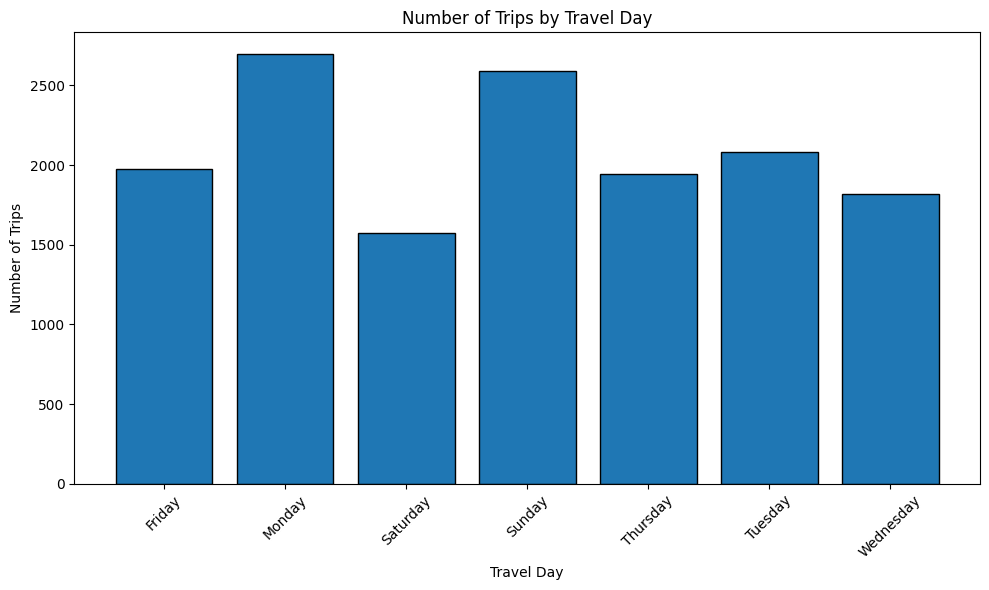

In [7]:
# Bar chart: number of trips by travel day
travel_day_counts = nhts_subset['travel_day'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(travel_day_counts.index, travel_day_counts.values, edgecolor='black')
plt.xlabel('Travel Day')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Travel Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

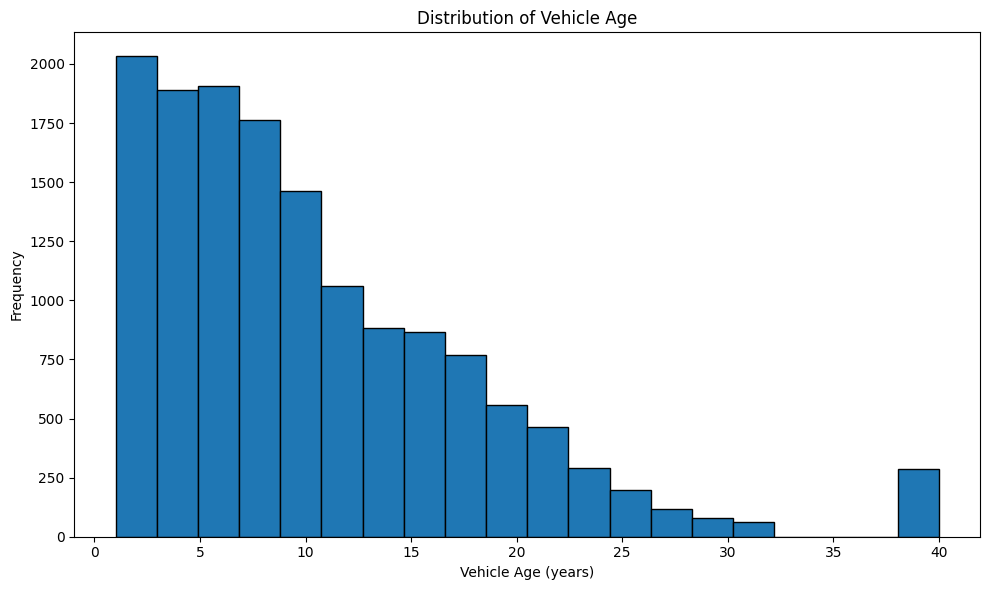

In [8]:
# Histogram: distribution of vehicle age
plt.figure(figsize=(10, 6))
plt.hist(nhts_subset['vehicle_age'], bins=20, edgecolor='black')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Frequency')
plt.title('Distribution of Vehicle Age')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

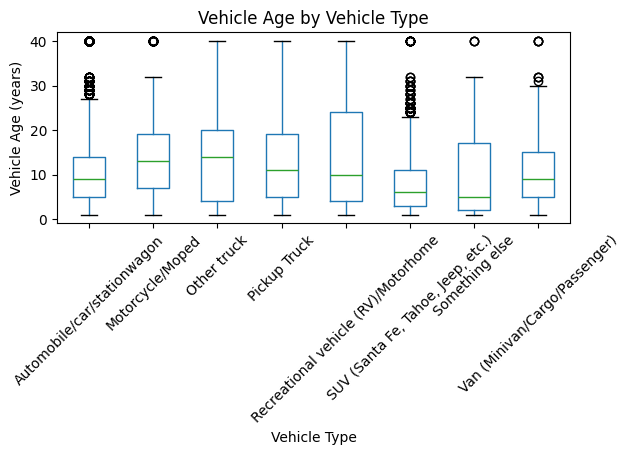

In [9]:
# Boxplot: vehicle age grouped by vehicle type
plt.figure(figsize=(12, 6))
nhts_subset.boxplot(column='vehicle_age', by='vehicle_type', grid=False)
plt.xlabel('Vehicle Type')
plt.ylabel('Vehicle Age (years)')
plt.title('Vehicle Age by Vehicle Type')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

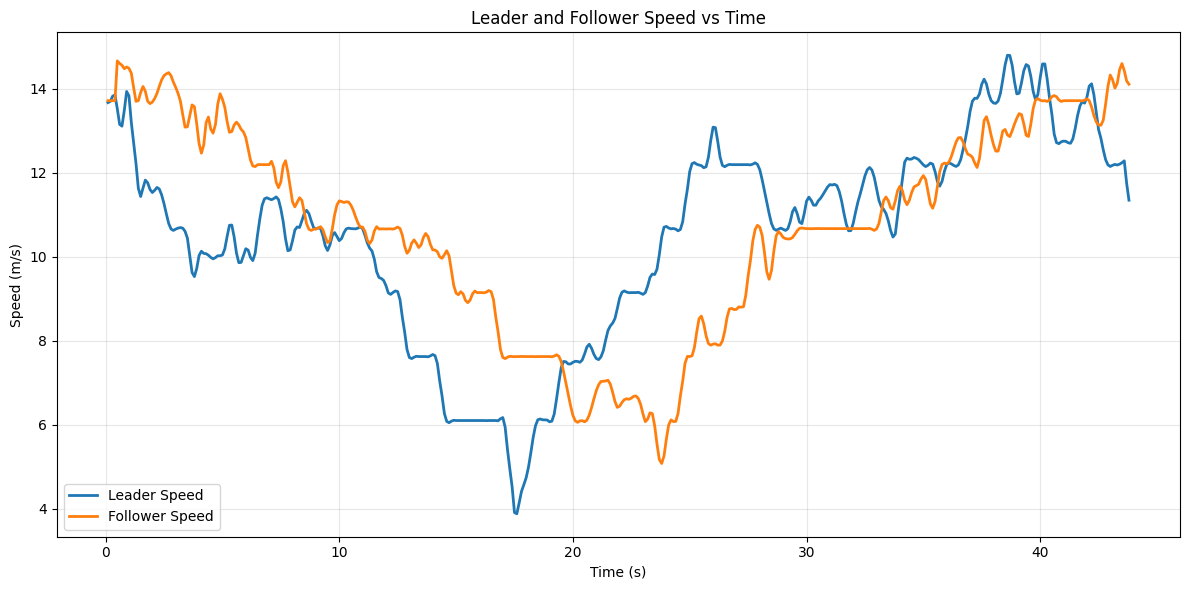

In [10]:
# Time-series plot 1: leader and follower speed over time
plt.figure(figsize=(12, 6))
plt.plot(
    trajectory_data['Time'],
    trajectory_data['leader_speed(m/s)'],
    label='Leader Speed',
    linewidth=2
)
plt.plot(
    trajectory_data['Time'],
    trajectory_data['follower_speed(m/s)'],
    label='Follower Speed',
    linewidth=2
)
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Leader and Follower Speed vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

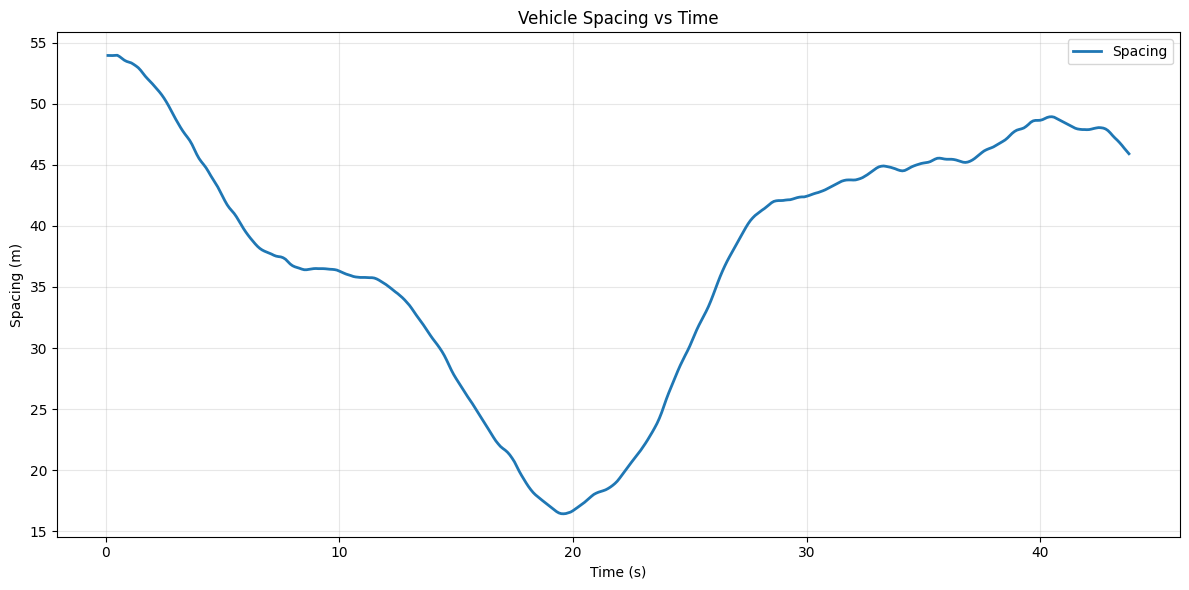

In [11]:
# Time-series plot 2: spacing over time
plt.figure(figsize=(12, 6))
plt.plot(
    trajectory_data['Time'],
    trajectory_data['spacing'],
    label='Spacing',
    linewidth=2
)
plt.xlabel('Time (s)')
plt.ylabel('Spacing (m)')
plt.title('Vehicle Spacing vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Define the IDM acceleration function
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)
    acceleration = a * (1 - (v / v0) ** delta - (s_star / s) ** 2)
    return acceleration

In [13]:
# Pull the arrays needed for the simulation
time_data = trajectory_data['Time'].values
leader_position = trajectory_data['leader_position(m)'].values
leader_speed = trajectory_data['leader_speed(m/s)'].values
real_follower_position = trajectory_data['follower_position(m)'].values
real_follower_speed = trajectory_data['follower_speed(m/s)'].values
real_follower_acc = trajectory_data['follower_acc(m/s^2)'].values

# Set the time step
dt = 0.1

# IDM parameters
v0 = 30
s0 = 2
T = 1.5
a = 1.0
b = 1.5
delta = 4

# Create arrays for the simulated results
n_steps = len(time_data)
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)

# Start the simulation from the real follower's first values
sim_position[0] = real_follower_position[0]
sim_speed[0] = real_follower_speed[0]

In [14]:
# Run the IDM simulation through time
for i in range(n_steps - 1):
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]

    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a, b, delta)

    sim_speed[i + 1] = max(sim_speed[i] + sim_acc[i] * dt, 0)
    sim_position[i + 1] = sim_position[i] + sim_speed[i] * dt

print("Simulation complete.")

Simulation complete.


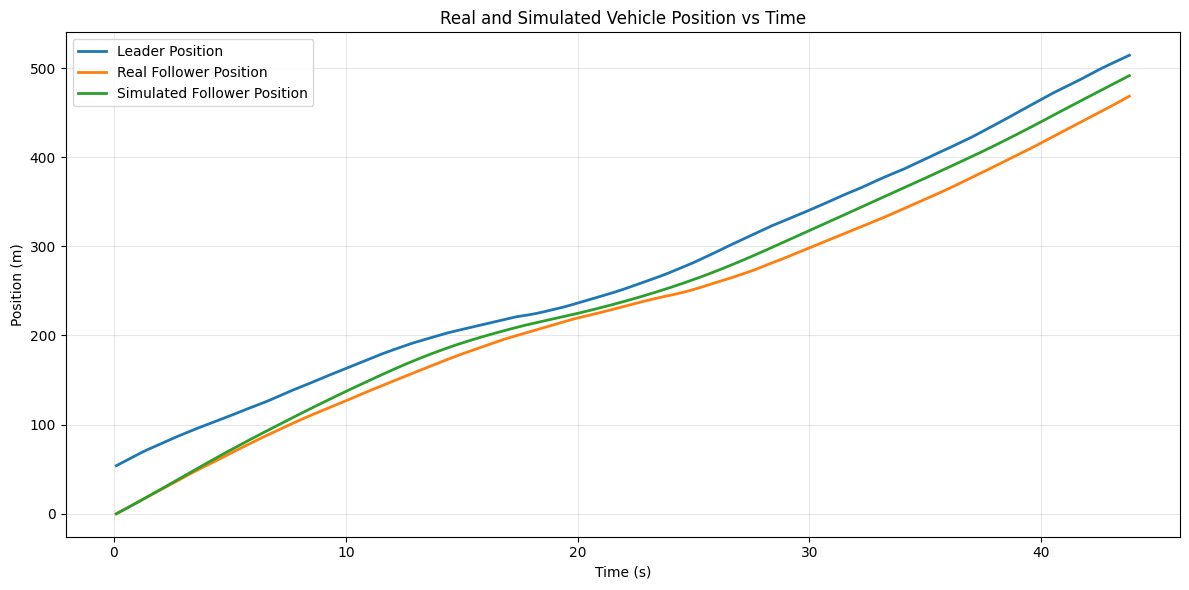

In [15]:
# Compare leader, real follower, and simulated follower positions
plt.figure(figsize=(12, 6))
plt.plot(time_data, leader_position, label='Leader Position', linewidth=2)
plt.plot(time_data, real_follower_position, label='Real Follower Position', linewidth=2)
plt.plot(time_data, sim_position, label='Simulated Follower Position', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Real and Simulated Vehicle Position vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

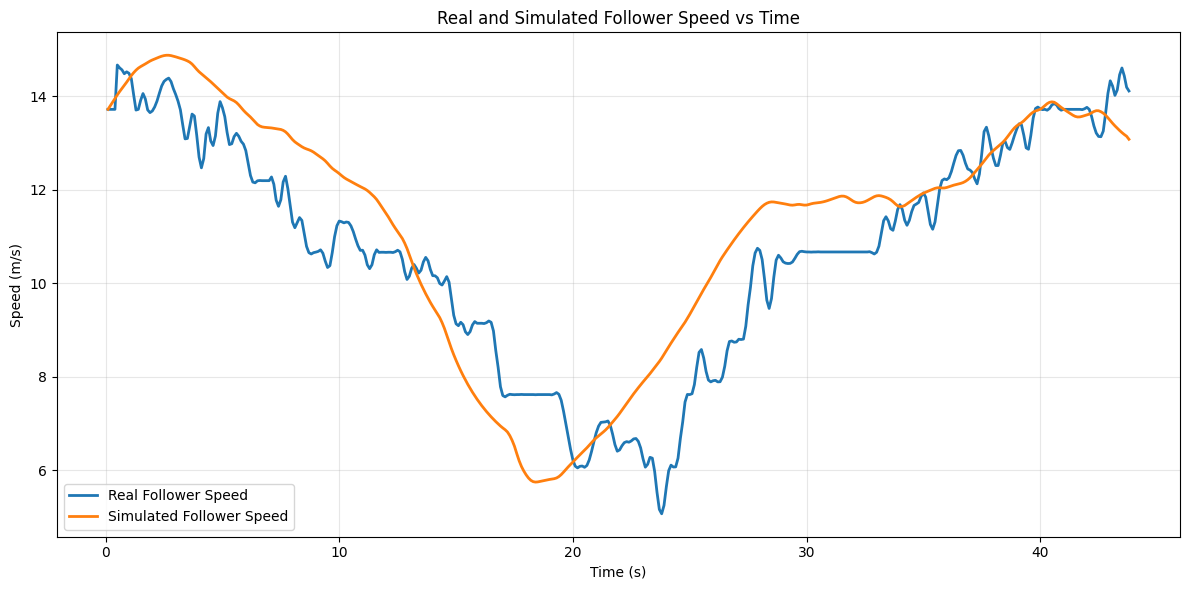

In [16]:
# Compare real and simulated follower speed
plt.figure(figsize=(12, 6))
plt.plot(time_data, real_follower_speed, label='Real Follower Speed', linewidth=2)
plt.plot(time_data, sim_speed, label='Simulated Follower Speed', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Real and Simulated Follower Speed vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

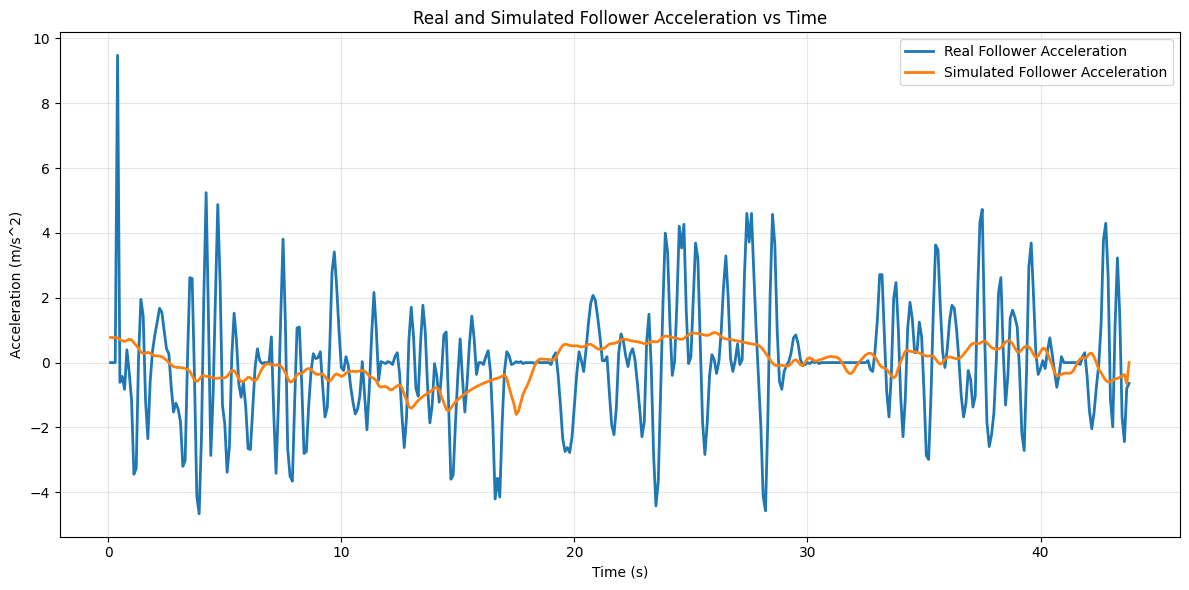

In [17]:
# Compare real and simulated follower acceleration
plt.figure(figsize=(12, 6))
plt.plot(time_data, real_follower_acc, label='Real Follower Acceleration', linewidth=2)
plt.plot(time_data, sim_acc, label='Simulated Follower Acceleration', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Real and Simulated Follower Acceleration vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

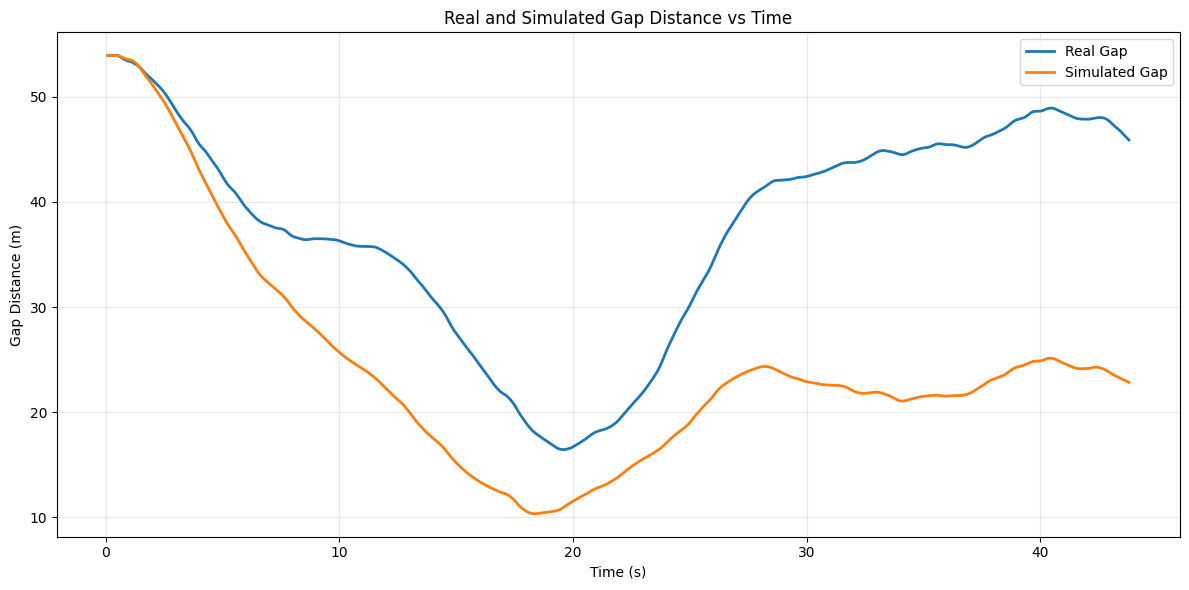

In [18]:
# Compare the real and simulated gap distance
real_gap = leader_position - real_follower_position
sim_gap = leader_position - sim_position

plt.figure(figsize=(12, 6))
plt.plot(time_data, real_gap, label='Real Gap', linewidth=2)
plt.plot(time_data, sim_gap, label='Simulated Gap', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Gap Distance (m)')
plt.title('Real and Simulated Gap Distance vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()